In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
# Cell 2 — Version 1: build a simple neural network with nn.Module
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = SimpleNN(input_size=2, hidden_size=4, output_size=1)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

# test with dummy input
x_dummy = torch.randn(5, 2)
out     = model(x_dummy)
print(f"\nInput shape:  {x_dummy.shape}")
print(f"Output shape: {out.shape}")
print(f"Output:       {out.detach()}")

SimpleNN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 17

Input shape:  torch.Size([5, 2])
Output shape: torch.Size([5, 1])
Output:       tensor([[0.3739],
        [0.3781],
        [0.3765],
        [0.3802],
        [0.3802]])


Training:

Epoch    0 | Loss=0.7236
Epoch  200 | Loss=0.3013
Epoch  400 | Loss=0.2972
Epoch  600 | Loss=0.2903
Epoch  800 | Loss=0.2609

Test Accuracy: 96.7%


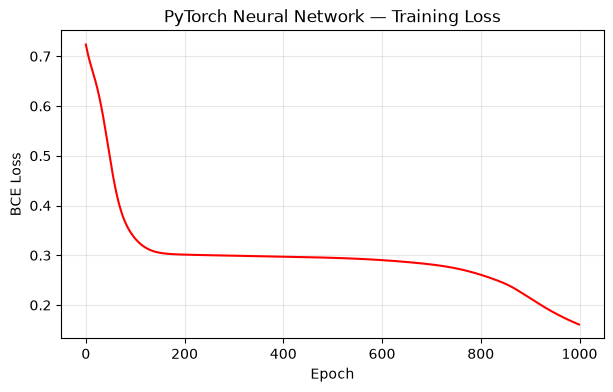

In [3]:
# Cell 3 — Version 2: training loop on moons dataset
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X    = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

# convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

model     = SimpleNN(2, 8, 1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
print("Training:\n")
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss   = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss={loss.item():.4f}")

# evaluate
model.eval()
with torch.no_grad():
    preds = (model(X_test_t) >= 0.5).float()
    acc   = (preds == y_test_t).float().mean()
print(f"\nTest Accuracy: {acc.item()*100:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot(losses, 'r-', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('PyTorch Neural Network — Training Loss')
plt.grid(True, alpha=0.3); plt.show()

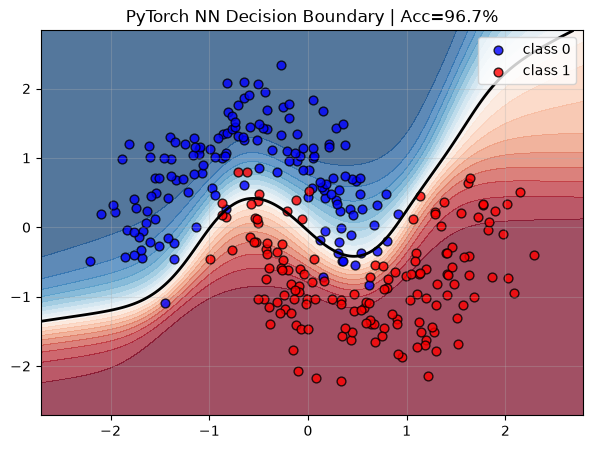

In [4]:
# Cell 4 — Version 3: decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
grid_t = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    Z = model(grid_t).numpy().reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=40,
            edgecolors='k', alpha=0.8, label='class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red',  s=40,
            edgecolors='k', alpha=0.8, label='class 1')
plt.title(f'PyTorch NN Decision Boundary | Acc={acc.item()*100:.1f}%')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Deeper Network Test Accuracy: 96.7%
Parameters: 225


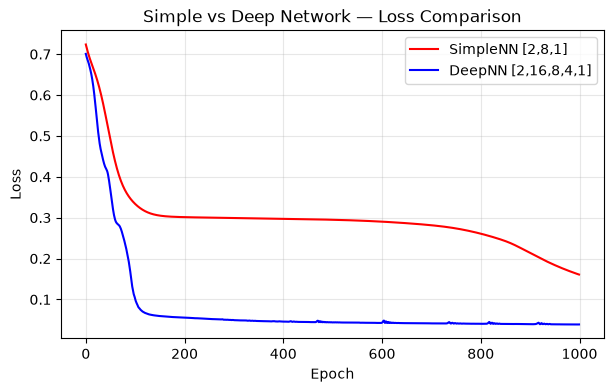

In [5]:
# Cell 5 — Version 4: deeper network with nn.Sequential
model2 = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

optimizer2 = optim.Adam(model2.parameters(), lr=0.01)
losses2    = []

for epoch in range(1000):
    model2.train()
    optimizer2.zero_grad()
    out  = model2(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer2.step()
    losses2.append(loss.item())

model2.eval()
with torch.no_grad():
    preds2 = (model2(X_test_t) >= 0.5).float()
    acc2   = (preds2 == y_test_t).float().mean()

print(f"Deeper Network Test Accuracy: {acc2.item()*100:.1f}%")
print(f"Parameters: {sum(p.numel() for p in model2.parameters())}")

plt.figure(figsize=(7, 4))
plt.plot(losses,  'r-', linewidth=1.5, label='SimpleNN [2,8,1]')
plt.plot(losses2, 'b-', linewidth=1.5, label='DeepNN [2,16,8,4,1]')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Simple vs Deep Network — Loss Comparison')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()